In [26]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import sys
!{sys.executable} -m pip install scikit-learn

In [31]:
import sys
print(sys.executable)

C:\Users\CHIBUDOM\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import sys
!{sys.executable} -m pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

All required libraries for machine learning was installed. These libraries will provide tools for building machine learning models.
This setup ensures all necessary dependencies are available for the full churn prediction workflow

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\CHIBUDOM\OneDrive\Documents\Assignment_Customer_Churn_Classification\Telco_Cusomer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


The necessary libraries were imported, and df.head() was used to display the first five rows of the dataset. This provided an initial overview of the data, including the column names and the types of values contained within each column. It also helped in understanding the overall structure of the dataset before proceeding

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The df.info() function was used to display a summary of the dataset. This output provided the number of non-null entries and the data types for each column. This information is important for data cleaning, as it helps identify columns with missing values that may need to be filled or removed, and ensures that each column has the appropriate data type for analysis.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

'TotalCharges' column was converted to numeric format.Any non-numeric values are replaced with NaN (errors='coerce')then missing values are filled with 0 to ensure the column is usable for analysis

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The df.info() function was used again to verify that all changes were successfully applied.

In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The df.isnull() function was used to check for missing values in each column by counting the number of null entries

In [13]:
df.duplicated().sum()

np.int64(0)

The df.duplicated() function was used to count the number of duplicate rows in the dataset

In [14]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

The df.describe was used to generate a summary of the dataset

In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

The 'Churn' column was cobnverted from categorical values (Yes/No) to numerical values (1/0) for machine learning models

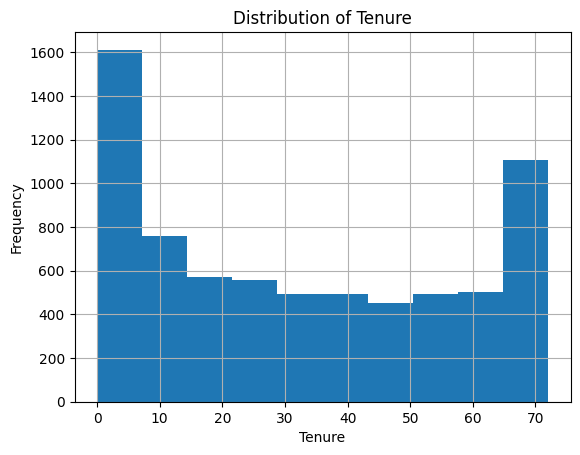

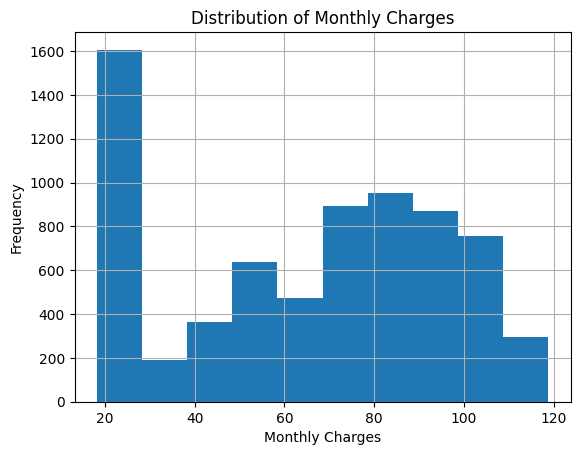

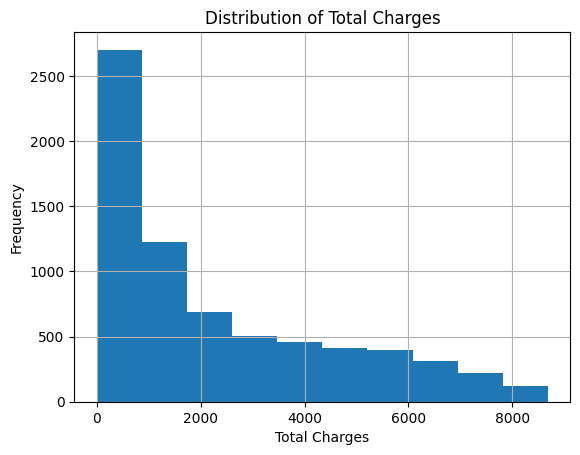

In [16]:
df['tenure'].hist()
plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

df['MonthlyCharges'].hist()
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

df['TotalCharges'].hist()
plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.show()

Histograms was used to visualize the distribution of key numerical features (tenure, MonthlyCharges, TotalCharges),
helping to understand how values are spread across the dataset and identify patterns such as skewness or concentration

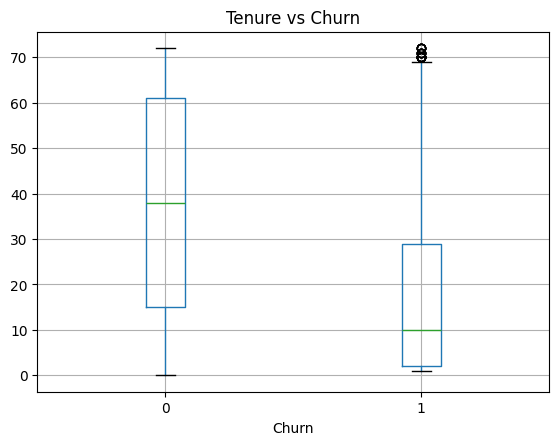

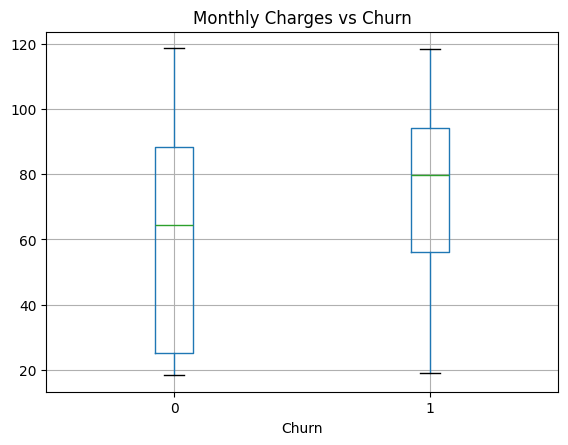

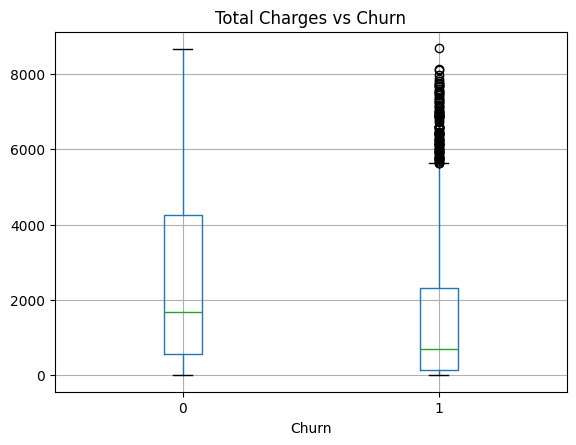

In [17]:
df.boxplot(column='tenure', by='Churn')
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.show()

df.boxplot(column='MonthlyCharges', by='Churn')
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.show()

df.boxplot(column='TotalCharges', by='Churn')
plt.title("Total Charges vs Churn")
plt.suptitle("")
plt.show()

Boxplots was used to compare numerical features against the target variable (Churn)and to identify potential outliers and differences in distribution between churned and non-churned customers

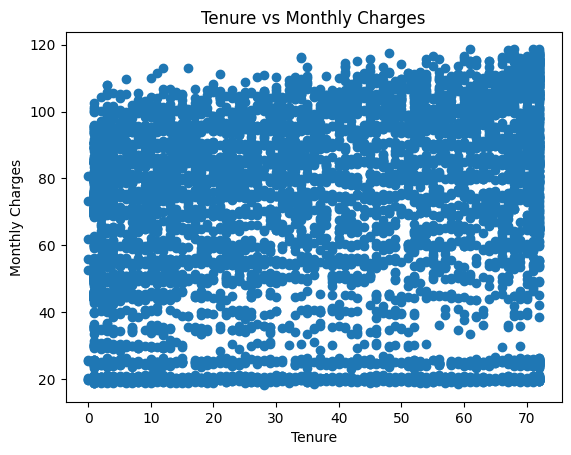

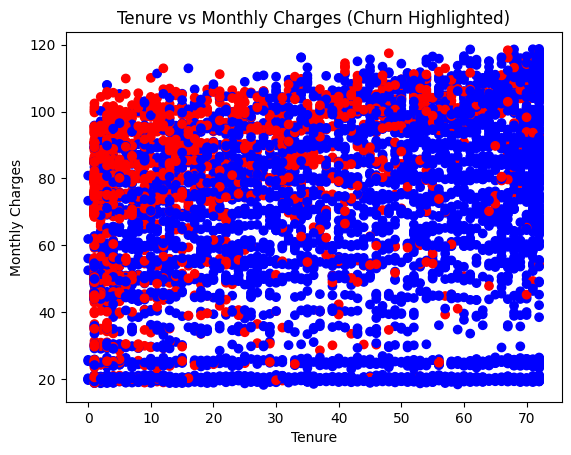

In [18]:
plt.scatter(df['tenure'], df['MonthlyCharges'])
plt.title("Tenure vs Monthly Charges")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

colors = df['Churn'].map({0: 'blue', 1: 'red'})

plt.scatter(df['tenure'], df['MonthlyCharges'], c=colors)
plt.title("Tenure vs Monthly Charges (Churn Highlighted)")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

Scatter plots were used to explore the relationship between tenure and monthly charges.
The second plot highlights churn status using different colors, making it easier to observe
any visible patterns or differences between customers who churned and those who did not.

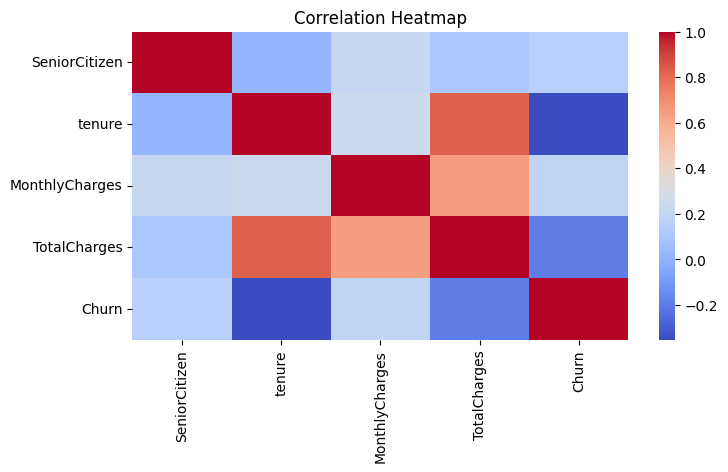

In [19]:
plt.figure(figsize=(8,4))

sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Heatmap was used to visualize correlations between numerical features,helping to identify relationships between variables and detect potential multicollinearity

<Axes: xlabel='Churn'>

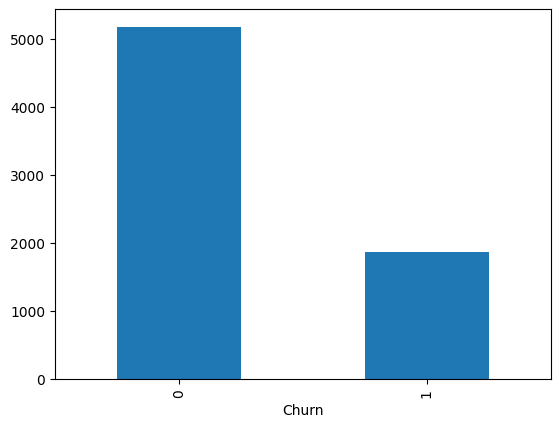

In [20]:
df['Churn'].value_counts().plot(kind='bar')

The distribution of the target variable (Churn) was plotted to understand class balance.
This helps to see how many customers churned vs those who did not

<Axes: xlabel='Contract'>

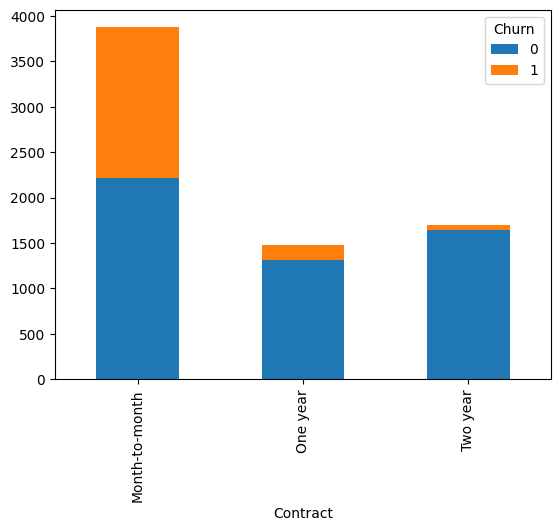

In [21]:
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', stacked=True)

The stacked bar chart is used to examine the relationship between contract type and churn.
This helps identify whether customers on different contract plans are more likely to churn

<Axes: xlabel='InternetService'>

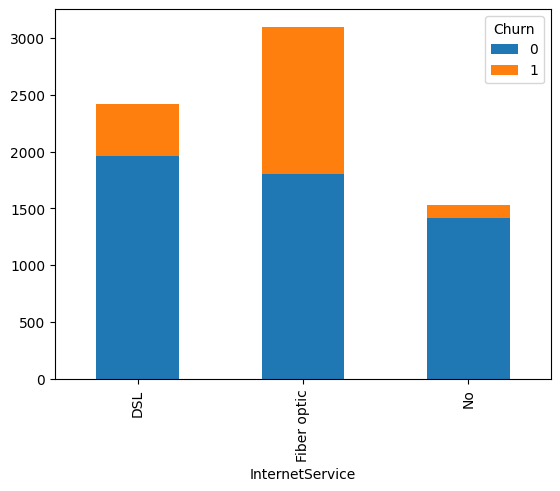

In [22]:
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar', stacked=True)

The stacked bar chart is used to explore how internet service type relates to churn.
This helps reveal patterns in churn behavior across different service categories

In [24]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

categorical_cols = df.select_dtypes(include=['object', 'string']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True) is used to select categorical columns and convert them into numerical format using onehot encoding, drop_first=True avoids redundancy by removing one category from each feature


In [29]:
X = df.drop('Churn', axis=1)
y = df['Churn']

The dataset was separated into input features (X) and the target variable (y), where ‘Churn’ represents the dependent variable to be predicted

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training and testing sets using an 80:20 ratio
The training set is used to train the model, while the test set is used to evaluate performance on unseen data.
random_state ensures the split is reproducible.

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

C:\Users\CHIBUDOM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model is trained on the data to learn patterns between features and customer churn.
The max_iter=1000 is set to ensure the model converges during training.
The trained model is then used to predict churn on the test dataset.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

The Random Forest Classifier is trained on the data to capture complex and non-linear relationships in the dataset.
The model builds multiple decision trees and combines their outputs for improved prediction accuracy.
The trained model is then used to predict customer churn on the test dataset

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))

print("\nRandom Forest:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Logistic Regression:
Accuracy: 0.8112136266855926
Precision: 0.6666666666666666
Recall: 0.5737265415549598
F1: 0.6167146974063401

Random Forest:
Accuracy: 0.7955997161107168
Precision: 0.6748971193415638
Recall: 0.43967828418230565
F1: 0.5324675324675324


Logistic Regression performed slightly better overall with higher accuracy, recall, and F1-score, making it more effective at identifying churned customers. Random Forest achieved slightly higher precision but had lower recall meaning it missed more actual churn cases.

In [40]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights = y_train.map(weights_dict)

mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train, sample_weight=sample_weights)

mlp_pred = mlp.predict(X_test_scaled)

print("Neural Network Results:")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("Precision:", precision_score(y_test, mlp_pred))
print("Recall:", recall_score(y_test, mlp_pred))
print("F1:", f1_score(y_test, mlp_pred))

Neural Network Results:
Accuracy: 0.7352732434350603
Precision: 0.0
Recall: 0.0
F1: 0.0


C:\Users\CHIBUDOM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_balanced, y_train_balanced)
mlp_pred = mlp.predict(X_test_scaled)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Neural Network Results (SMOTE):")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("Precision:", precision_score(y_test, mlp_pred))
print("Recall:", recall_score(y_test, mlp_pred))
print("F1:", f1_score(y_test, mlp_pred))

Neural Network Results (SMOTE):
Accuracy: 0.7352732434350603
Precision: 0.0
Recall: 0.0
F1: 0.0


C:\Users\CHIBUDOM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


The neural network model exhibited class prediction collapse, where it predicted only the majority class (non-churn customers). This resulted in zero precision and recall for the minority class.

In [42]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),   
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,             
    validation_fraction=0.2,
    random_state=42
)
mlp.fit(X_train_balanced, y_train_balanced)
mlp_pred = mlp.predict(X_test_scaled)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Improved Deep Learning Model Results:")
print("Accuracy:", accuracy_score(y_test, mlp_pred))
print("Precision:", precision_score(y_test, mlp_pred))
print("Recall:", recall_score(y_test, mlp_pred))
print("F1:", f1_score(y_test, mlp_pred))

Improved Deep Learning Model Results:
Accuracy: 0.26472675656493966
Precision: 0.26472675656493966
Recall: 1.0
F1: 0.4186307519640853


The deep learning model showed high recall but low precision showing that while it successfully identified all churn cases, it also incorrectly classified many non-churn customers as churn. This reflects an overcompensation effect caused by class imbalance handling techniques such as SMOTE.
Model performance was evaluated using accuracy, precision, recall, and F1score. Accuracy measures overall correctness, while precision and recall provide insight into the model’s ability to correctly identify churn cases, and the F1-score provides a balance between precision and recall.
Overall Logistic Regression provided the best balance between accuracy, precision, and recall, making it the most suitable model for churn prediction in this study